# COMP 262 Phase 2 Code

Machine learning sentiment analysis, model comparison, rating enhancement, and LLM tasks for the All Beauty dataset.

## Setup and imports

In [11]:
# -*- coding: utf-8 -*-
# COMP 262 - Phase 2: Machine Learning Sentiment Analysis
# Team #2: All Beauty Dataset

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings
warnings.filterwarnings("ignore")

# download nltk data if not already cached
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

def label_sentiment(rating):
    """Map a numeric star rating to Positive, Neutral, or Negative."""
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"


print("PHASE 2 – Machine Learning Sentiment Analysis")

PHASE 2 – Machine Learning Sentiment Analysis


## Load dataset and prepare Phase 1 comparison sample

In [12]:

# --- start: reproducing phase 1 sample so these reviews stay out of ML training ---
# df_raw = pd.read_json("All_Beauty.json", lines=True)

base_path = os.getcwd()
json_path = os.path.join(base_path, "All_Beauty.json")
df_raw = pd.read_json(json_path, lines=True)

df_raw["reviewText"] = df_raw["reviewText"].fillna("")
df_raw["summary"]    = df_raw["summary"].fillna("")
df_raw["full_text"]  = df_raw["summary"] + " " + df_raw["reviewText"]
df_raw["sentiment"]  = df_raw["overall"].apply(label_sentiment)

# same two filters phase 1 applied before sampling
df_raw["review_length"] = df_raw["reviewText"].apply(lambda x: len(str(x)))
df_raw["review_len"]    = df_raw["full_text"].apply(len)
df_p1_pool = df_raw[(df_raw["review_length"] > 3) & (df_raw["review_len"] > 2)].copy()
df_compare = df_p1_pool.sample(n=min(1000, len(df_p1_pool)), random_state=77).copy()
# --- end: phase 1 sample reproduced ---

# build a unique key per review so we can track which ones to exclude from training
compare_keys = set(
    zip(df_compare["reviewerID"], df_compare["asin"], df_compare["reviewText"])
)

# remove those 1000 reviews from the ML pool so they cant end up in training, used for the final lexicon vs ML comparison at the end
df_ml_pool = df_raw[df_raw["review_len"] > 10].copy()
df_ml_pool["_key"] = list(zip(
    df_ml_pool["reviewerID"], df_ml_pool["asin"], df_ml_pool["reviewText"]
))
df_ml_pool = df_ml_pool[~df_ml_pool["_key"].isin(compare_keys)]
df_ml_pool = df_ml_pool.drop(columns=["_key", "review_length"]).reset_index(drop=True)

# stratified sample of 2500 so class proportions match the full dataset
sss = StratifiedShuffleSplit(n_splits=1, test_size=2500, random_state=42)
_, idx = next(sss.split(df_ml_pool, df_ml_pool["sentiment"]))
df_ml = df_ml_pool.iloc[idx].reset_index(drop=True)


## Create Phase 2 ML subset

In [13]:
print(f"\nML Subset Shape: {df_ml.shape}")
print("\nClass distribution in ML subset:")
print(df_ml["sentiment"].value_counts())
print(f"\nRating value distribution in ML subset:")
print(df_ml["overall"].value_counts().sort_index())


ML Subset Shape: (2500, 15)

Class distribution in ML subset:
sentiment
Positive    1900
Negative     401
Neutral      199
Name: count, dtype: int64

Rating value distribution in ML subset:
overall
1     263
2     138
3     199
4     369
5    1531
Name: count, dtype: int64


## Data exploration on ML subset


Data Exploration – ML Subset

Total reviews:    2500
Unique products:  1596
Unique reviewers: 2496
Average rating:   4.11

Word-count statistics:
count    2500.00
mean       41.99
std        56.48
min         1.00
25%        10.00
50%        25.00
75%        51.00
max       936.00
Name: word_count, dtype: float64


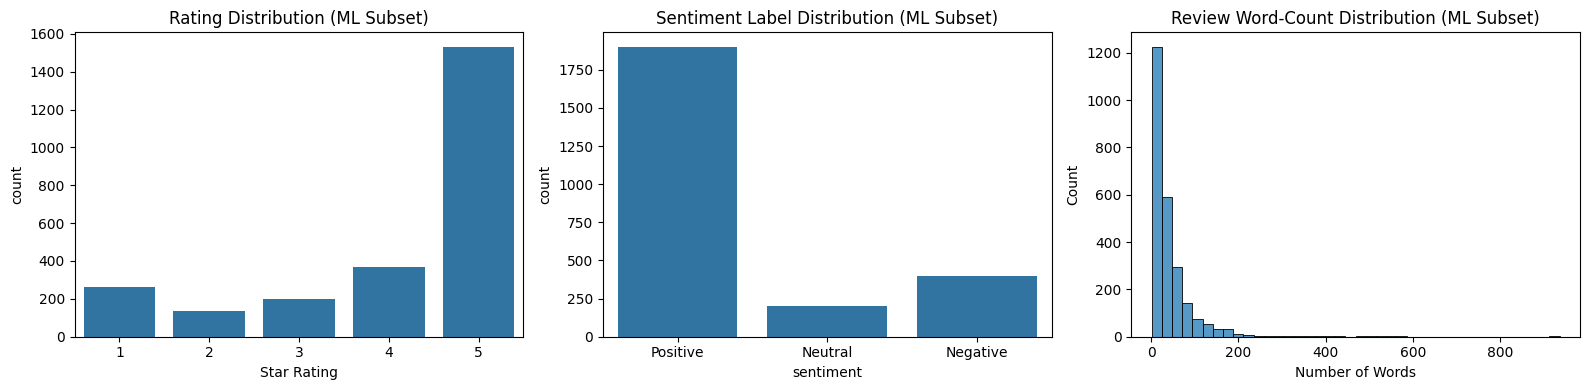

In [14]:
print("\n" + "=" * 60)
print("Data Exploration – ML Subset")
print("=" * 60)

print(f"\nTotal reviews:    {len(df_ml)}")
print(f"Unique products:  {df_ml['asin'].nunique()}")
print(f"Unique reviewers: {df_ml['reviewerID'].nunique()}")
print(f"Average rating:   {df_ml['overall'].mean():.2f}")

# word count for exploration
df_ml["word_count"] = df_ml["full_text"].apply(lambda x: len(x.split()))
print("\nWord-count statistics:")
print(df_ml["word_count"].describe().round(2))

# plot rating distribution, sentiment labels, and review word counts
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x="overall", data=df_ml, ax=axes[0])
axes[0].set_title("Rating Distribution (ML Subset)")
axes[0].set_xlabel("Star Rating")

sns.countplot(
    x="sentiment", data=df_ml, ax=axes[1],
    order=["Positive", "Neutral", "Negative"]
)
axes[1].set_title("Sentiment Label Distribution (ML Subset)")

sns.histplot(df_ml["word_count"], bins=40, ax=axes[2])
axes[2].set_title("Review Word-Count Distribution (ML Subset)")
axes[2].set_xlabel("Number of Words")

plt.tight_layout()
plt.savefig("ml_subset_exploration.png", dpi=150)
plt.show()

## Text preprocessing and TF-IDF representation

In [15]:
print("\n" + "=" * 60)
print("Text Pre-processing & TF-IDF Representation")
print("=" * 60)

# lowercase, strip urls and non-alpha chars, remove stopwords, then lemmatize
stop_words  = set(stopwords.words("english"))
lemmatizer  = WordNetLemmatizer()

def preprocess_ml(text):
    """Clean text for ML: lowercase, remove URLs/punctuation, drop stopwords, lemmatize."""
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return " ".join(tokens)

print("Applying ML pre-processing pipeline...")
df_ml["text_clean"] = df_ml["full_text"].apply(preprocess_ml)


print("\n" + "=" * 60)
print("Stratified 70/30 Train-Test Split")
print("=" * 60)

X = df_ml["text_clean"]
y = df_ml["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=df_ml["overall"],
    random_state=42
)

print(f"Training set size: {len(X_train)} ({len(X_train)/len(X_train+X_test)*100:.0f}%)")
print(f"Test set size:     {len(X_test)}  ({len(X_test)/len(X_train+X_test)*100:.0f}%)")
print("\nTraining label distribution:")
print(y_train.value_counts())
print("\nTest label distribution:")
print(y_test.value_counts())

# fit the vectorizer only on training data so we don't leak info from the test set
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=20_000,
    sublinear_tf=True,
    min_df=2
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nTF-IDF vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"Training matrix shape:  {X_train_tfidf.shape}")
print(f"Test matrix shape:      {X_test_tfidf.shape}")


Text Pre-processing & TF-IDF Representation
Applying ML pre-processing pipeline...

Stratified 70/30 Train-Test Split
Training set size: 1750 (70%)
Test set size:     750  (30%)

Training label distribution:
sentiment
Positive    1330
Negative     281
Neutral      139
Name: count, dtype: int64

Test label distribution:
sentiment
Positive    570
Negative    120
Neutral      60
Name: count, dtype: int64

TF-IDF vocabulary size: 5,218
Training matrix shape:  (1750, 5218)
Test matrix shape:      (750, 5218)


## Model training and fine tuning

In [16]:
print("\n" + "=" * 60)
print("Model Training & Fine-Tuning")
print("=" * 60)

# tune C with 5-fold cross validation, using macro F1 to handle class imbalance
print("\n--- Training Logistic Regression ---")
lr_params = {"C": [0.1, 1.0, 10.0], "max_iter": [1000]}
lr_grid = GridSearchCV(
    LogisticRegression(class_weight="balanced", solver="lbfgs", random_state=42),
    lr_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
lr_grid.fit(X_train_tfidf, y_train)
best_lr = lr_grid.best_estimator_

print(f"Best parameters:    {lr_grid.best_params_}")
print(f"Best CV F1 (macro): {lr_grid.best_score_:.4f}")

lr_train_pred = best_lr.predict(X_train_tfidf)
print(f"\nTraining Accuracy: {accuracy_score(y_train, lr_train_pred):.4f}")
print(classification_report(y_train, lr_train_pred, zero_division=0))

# same tuning approach for SVM
print("\n--- Training Linear SVM ---")
svm_params = {"C": [0.1, 1.0, 10.0]}
svm_grid = GridSearchCV(
    LinearSVC(class_weight="balanced", random_state=42, max_iter=2000),
    svm_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
svm_grid.fit(X_train_tfidf, y_train)
best_svm = svm_grid.best_estimator_

print(f"Best parameters:    {svm_grid.best_params_}")
print(f"Best CV F1 (macro): {svm_grid.best_score_:.4f}")

svm_train_pred = best_svm.predict(X_train_tfidf)
print(f"\nTraining Accuracy: {accuracy_score(y_train, svm_train_pred):.4f}")
print(classification_report(y_train, svm_train_pred, zero_division=0))


Model Training & Fine-Tuning

--- Training Logistic Regression ---
Best parameters:    {'C': 10.0, 'max_iter': 1000}
Best CV F1 (macro): 0.6923

Training Accuracy: 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       281
     Neutral       1.00      1.00      1.00       139
    Positive       1.00      1.00      1.00      1330

    accuracy                           1.00      1750
   macro avg       1.00      1.00      1.00      1750
weighted avg       1.00      1.00      1.00      1750


--- Training Linear SVM ---
Best parameters:    {'C': 10.0}
Best CV F1 (macro): 0.6960

Training Accuracy: 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       281
     Neutral       1.00      1.00      1.00       139
    Positive       1.00      1.00      1.00      1330

    accuracy                           1.00      1750
   macro avg       1.00      1.00      1.00      1750
weight

## Testing and ML model evaluation


Testing on 30% Held-Out Test Set

────────────────────────────────────────
  Logistic Regression – Test Set
────────────────────────────────────────
  Accuracy:            0.8720
  Precision (macro):   0.7553
  Recall    (macro):   0.6860
  F1 Score  (macro):   0.7141

              precision    recall  f1-score   support

    Negative       0.77      0.70      0.73       120
     Neutral       0.59      0.40      0.48        60
    Positive       0.91      0.96      0.93       570

    accuracy                           0.87       750
   macro avg       0.76      0.69      0.71       750
weighted avg       0.86      0.87      0.86       750


────────────────────────────────────────
  Linear SVM          – Test Set
────────────────────────────────────────
  Accuracy:            0.8640
  Precision (macro):   0.7492
  Recall    (macro):   0.6665
  F1 Score  (macro):   0.6999

              precision    recall  f1-score   support

    Negative       0.79      0.66      0.72       120
  

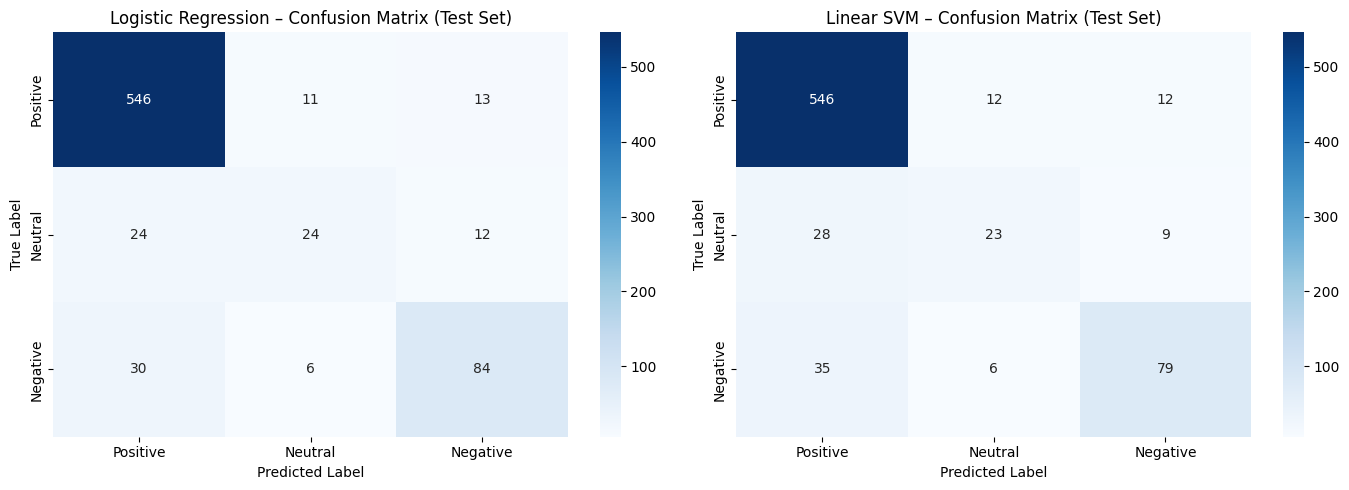


--- ML Models Summary (Test Set) ---
              Model  Accuracy  Precision (M)  Recall (M)  F1 Macro
Logistic Regression     0.872         0.7553      0.6860    0.7141
         Linear SVM     0.864         0.7492      0.6665    0.6999


In [17]:
print("\n" + "=" * 60)
print("Testing on 30% Held-Out Test Set")
print("=" * 60)

def evaluate_model(name, y_true, y_pred):
    """Print accuracy, precision, recall, F1, and full classification report for one model."""
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    print(f"  Accuracy:            {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision (macro):   {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  Recall    (macro):   {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  F1 Score  (macro):   {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"\n{classification_report(y_true, y_pred, zero_division=0)}")

lr_test_pred  = best_lr.predict(X_test_tfidf)
svm_test_pred = best_svm.predict(X_test_tfidf)

evaluate_model("Logistic Regression – Test Set", y_test, lr_test_pred)
evaluate_model("Linear SVM          – Test Set", y_test, svm_test_pred)

# confusion matrices for both ML models on the test set
LABELS = ["Positive", "Neutral", "Negative"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, title in zip(
    axes,
    [lr_test_pred, svm_test_pred],
    ["Logistic Regression", "Linear SVM"]
):
    cm = confusion_matrix(y_test, pred, labels=LABELS)
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=LABELS, yticklabels=LABELS,
        ax=ax, cmap="Blues"
    )
    ax.set_title(f"{title} – Confusion Matrix (Test Set)")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.savefig("ml_test_confusion_matrices.png", dpi=150)
plt.show()

# summary table so both models are easy to compare side by side
print("\n--- ML Models Summary (Test Set) ---")
ml_summary = pd.DataFrame({
    "Model":           ["Logistic Regression", "Linear SVM"],
    "Accuracy":        [accuracy_score(y_test, lr_test_pred),
                        accuracy_score(y_test, svm_test_pred)],
    "Precision (M)":   [precision_score(y_test, lr_test_pred, average="macro", zero_division=0),
                        precision_score(y_test, svm_test_pred, average="macro", zero_division=0)],
    "Recall (M)":      [recall_score(y_test, lr_test_pred, average="macro", zero_division=0),
                        recall_score(y_test, svm_test_pred, average="macro", zero_division=0)],
    "F1 Macro":        [f1_score(y_test, lr_test_pred, average="macro", zero_division=0),
                        f1_score(y_test, svm_test_pred, average="macro", zero_division=0)],
})
print(ml_summary.round(4).to_string(index=False))

## Lexicon vs machine learning comparison


Lexicon vs ML – Apples-to-Apples Comparison
Using the same 1000-review sample as Phase 1 (random_state=77)
Comparison sample shape: (1000, 16)
Sentiment distribution in comparison sample:
sentiment
Positive    745
Negative    171
Neutral      84
Name: count, dtype: int64

--- All-Models Comparison (Same 1000-Review Sample) ---
              Model  Accuracy  Precision (M)  Recall (M)  F1 Macro
              VADER     0.771         0.5331      0.5058    0.5172
           TextBlob     0.759         0.5051      0.4623    0.4766
Logistic Regression     0.848         0.7231      0.6513    0.6805
         Linear SVM     0.842         0.7360      0.6250    0.6659


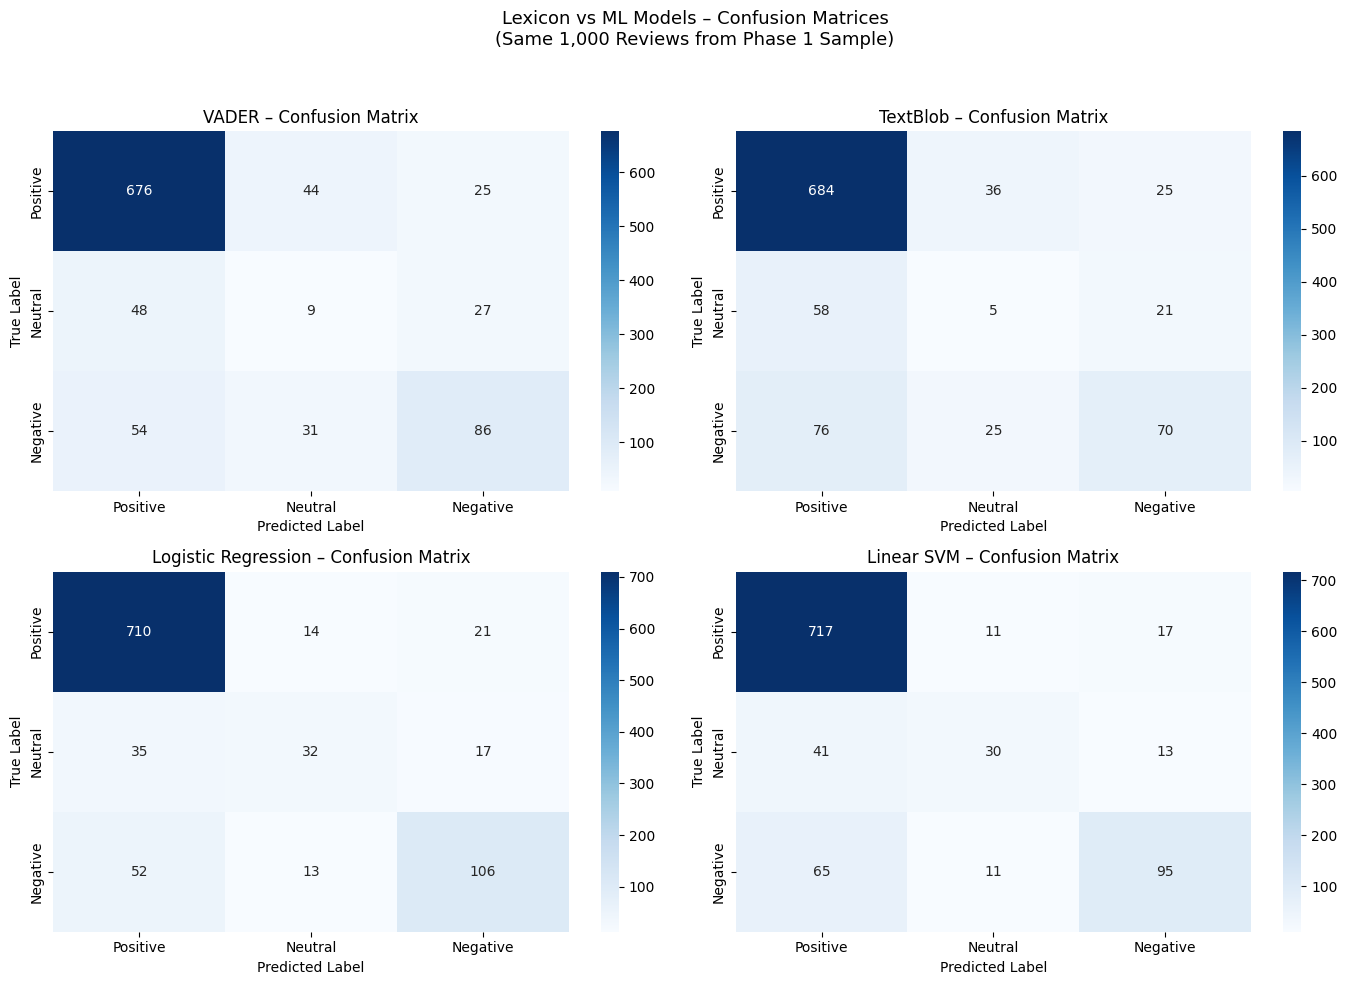


Phase 2 – ML Approach complete.
Saved plots:
  ml_subset_exploration.png
  ml_test_confusion_matrices.png
  comparison_all_models.png


In [18]:
print("\n" + "=" * 60)
print("Lexicon vs ML – Apples-to-Apples Comparison")
print("Using the same 1000-review sample as Phase 1 (random_state=77)")
print("=" * 60)

print(f"Comparison sample shape: {df_compare.shape}")
print("Sentiment distribution in comparison sample:")
print(df_compare["sentiment"].value_counts())

# same preprocessing functions from phase 1
def preprocess_vader(text):
    """Minimal cleaning for VADER: only remove URLs and extra whitespace."""
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def preprocess_textblob(text):
    """Stronger cleaning for TextBlob: lowercase, remove URLs, strip non-alpha chars."""
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df_compare["text_vader"] = df_compare["full_text"].apply(preprocess_vader)
df_compare["text_blob"]  = df_compare["full_text"].apply(preprocess_textblob)

vader_analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    """Return a sentiment label using VADER's compound score thresholds."""
    score = vader_analyzer.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

def textblob_sentiment(text):
    """Return a sentiment label using TextBlob's polarity score."""
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df_compare["pred_vader"]    = df_compare["text_vader"].apply(vader_sentiment)
df_compare["pred_textblob"] = df_compare["text_blob"].apply(textblob_sentiment)

# apply the ml preprocessing to the comparison set and transform with the already-fitted vectorizer
df_compare["text_clean"] = df_compare["full_text"].apply(preprocess_ml)
X_compare_tfidf = tfidf.transform(df_compare["text_clean"])

df_compare["pred_lr"]  = best_lr.predict(X_compare_tfidf)
df_compare["pred_svm"] = best_svm.predict(X_compare_tfidf)

y_compare = df_compare["sentiment"]

models_compare = {
    "VADER":               df_compare["pred_vader"],
    "TextBlob":            df_compare["pred_textblob"],
    "Logistic Regression": df_compare["pred_lr"],
    "Linear SVM":          df_compare["pred_svm"],
}

rows = []
for model_name, preds in models_compare.items():
    rows.append({
        "Model":          model_name,
        "Accuracy":       round(accuracy_score(y_compare, preds), 4),
        "Precision (M)":  round(precision_score(y_compare, preds, average="macro", zero_division=0), 4),
        "Recall (M)":     round(recall_score(y_compare, preds, average="macro", zero_division=0), 4),
        "F1 Macro":       round(f1_score(y_compare, preds, average="macro", zero_division=0), 4),
    })

final_comparison = pd.DataFrame(rows)
print("\n--- All-Models Comparison (Same 1000-Review Sample) ---")
print(final_comparison.to_string(index=False))

# 2x2 grid of confusion matrices for all four models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, (model_name, preds) in zip(axes, models_compare.items()):
    cm = confusion_matrix(y_compare, preds, labels=LABELS)
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=LABELS, yticklabels=LABELS,
        ax=ax, cmap="Blues"
    )
    ax.set_title(f"{model_name} – Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle(
    "Lexicon vs ML Models – Confusion Matrices\n(Same 1,000 Reviews from Phase 1 Sample)",
    fontsize=13, y=0.98
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("comparison_all_models.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "=" * 60)
print("Phase 2 – ML Approach complete.")
print("Saved plots:")
print("  ml_subset_exploration.png")
print("  ml_test_confusion_matrices.png")
print("  comparison_all_models.png")
print("=" * 60)

## Review based rating enhancement

In [19]:
# ENHANCING THE RATING VALUE
print("""
ENHANCING THE RATING VALUE
Star ratings alone do not always capture the full opinion of the reviewer. 
Reviews provide extra context, so we use the predicted overall sentiment 
from the review text to slightly increase or decrease the original star rating.""")

print("\nOPTION WE CHOSE: Rating profile - enhancing ratings with reviews\n")

print("""
DIAGRAM OF RATING ENHANCEMENT PROCESS:
      
Review text + original star rating
            |
            v
Clean review text
            |
            v
Convert text to TF-IDF features
            |
            v
Predict sentiment with Logistic Regression
            |
            v
Map sentiment to score (1, 0, -1)
            |
            v
Adjust original star rating
            |
            v
Create enhanced review score
            |
            v
Group by asin and calculate averages
            |
            v
Rank products by enhanced rating
""")

print("""
PSEUDO-CODE FOR RATING ENHANCEMENT:
1. clean the review text
2. predict sentiment from the review text
3. turn the sentiment into a small score (1, 0, -1)
4. add the score to the original star rating
5. calculate the updated rating for each product
6. rank the final results based on the enhanced rating
""")

print("\nReview-Based Rating Enhancement\n")

# making a copy of the original dataset so the rating enhancement process does not change the df_raw we used for ML training and testing
df_enhanced_rating = df_raw.copy()

# applying the same preprocessing methods
df_enhanced_rating["text_clean"] = df_enhanced_rating["full_text"].apply(preprocess_ml)

# transforming text using the fitted TF-IDF vectorizer
X_enhanced_rating_tfidf = tfidf.transform(df_enhanced_rating["text_clean"])

# using Logistic Regression to predict sentiment for each review
df_enhanced_rating["predicted_sentiment"] = best_lr.predict(X_enhanced_rating_tfidf)

# converting sentiment labels into numeric sentiment scores
sentiment_score_map = {
    "Positive": 1,
    "Neutral": 0,
    "Negative": -1
}
df_enhanced_rating["sentiment_score"] = df_enhanced_rating["predicted_sentiment"].map(sentiment_score_map)

# creating a review-level enhanced score
# star ratings are on a 1 to 5 scale, so sentiment is used as a small adjustment
df_enhanced_rating["enhanced_review_score"] = (
    df_enhanced_rating["overall"] + (0.5 * df_enhanced_rating["sentiment_score"])
).clip(1, 5)

# grouping the reviews by asin and calculating the final summary
product_scores_jason = df_enhanced_rating.groupby("asin").agg(
    average_star_rating=("overall", "mean"),
    review_count=("overall", "count"),
    average_sentiment_score=("sentiment_score", "mean"),
    enhanced_rating=("enhanced_review_score", "mean")
).reset_index()

# sorting products by enhanced rating, then by review count
product_scores_jason = product_scores_jason.sort_values(
    by=["enhanced_rating", "review_count"],
    ascending=[False, False]
)

# top 10 results based on the enhanced rating
print("\nTop 10 results based on enhanced rating:")
print(product_scores_jason.head(10).to_string(index=False))

# comparing original vs enhanced top products
top_original_jason = product_scores_jason.sort_values(
    by=["average_star_rating", "review_count"],
    ascending=[False, False]
).head(10)

# top 10 products based on original average
print("\nTop 10 products based on original average rating:")
print(top_original_jason.to_string(index=False))


# statistics summary
print("\nSummary of enhanced rating:")
print("Total products scored:", len(product_scores_jason))
print("Average original rating:", round(product_scores_jason["average_star_rating"].mean(), 4))
print("Average enhanced rating:", round(product_scores_jason["enhanced_rating"].mean(), 4))


ENHANCING THE RATING VALUE
Star ratings alone do not always capture the full opinion of the reviewer. 
Reviews provide extra context, so we use the predicted overall sentiment 
from the review text to slightly increase or decrease the original star rating.

OPTION WE CHOSE: Rating profile - enhancing ratings with reviews


DIAGRAM OF RATING ENHANCEMENT PROCESS:

Review text + original star rating
            |
            v
Clean review text
            |
            v
Convert text to TF-IDF features
            |
            v
Predict sentiment with Logistic Regression
            |
            v
Map sentiment to score (1, 0, -1)
            |
            v
Adjust original star rating
            |
            v
Create enhanced review score
            |
            v
Group by asin and calculate averages
            |
            v
Rank products by enhanced rating


PSEUDO-CODE FOR RATING ENHANCEMENT:
1. clean the review text
2. predict sentiment from the review text
3. turn the sent

## Step 16 LLM review summarization

In [20]:
# Step 16 - Summarize reviews with >100 words length into 50 words using HuggingFace LLM model

#get reviews with words length greater than 100 and get 10 reviews to summarize
df_review_100 = df_raw.copy()
reviews_100 = [text for text in df_review_100['reviewText'] if len(text.split()) > 100] 
reviews_10 = reviews_100[:10] 

# Load FLAN-T5 base from local Hugging Face cache.
# Run cache_flant5_base.py first to load model into the cache if not already cached.
MODEL_NAME = "google/flan-t5-base"
CACHE_DIR = "./hf_cache"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    cache_dir=CACHE_DIR,
    local_files_only=True
)

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    cache_dir=CACHE_DIR,
    local_files_only=True
)

def summarize_texts(num):
  input_text = "summarize: " + reviews_10[num]
  inputs = tokenizer(input_text, max_length=1024, truncation=True, return_tensors="pt") #set the input reviews to be summarized
  #set the output summarized reviews
  outputs = model.generate(
      inputs['input_ids'],
      min_new_tokens=50,
      max_new_tokens=75,
      num_beams=5,
      do_sample=False,
      length_penalty = 2.0, #generate longer sequences
      early_stopping=True,
      no_repeat_ngram_size=2 #prevent model from repeating phrases
      )
  #print each review and summarized review for each output 
  for i in range(len(outputs)):
    review_summary = tokenizer.decode(outputs[i], skip_special_tokens=True)
    print(f"Original: {reviews_10[num]}")
    print(f"Summary: {review_summary}\n")

#print the 10 original and summarized reviews
for i, review in enumerate(reviews_10):
  summarize_texts(i)

Loading weights: 100%|██████████| 282/282 [00:00<00:00, 2238.51it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Original: Today I gave a book about the Negro Leagues of Baseball to a traveling friend. Its a book I've read more than once and felt that my friend would truly enjoy. It felt like giving a gift that you wanted to keep for yourself. I parted with the book knowing that my friend would enjoy reading it on his journey back east. Before giving him the book I spent about thirty minutes flipping through its pages and saying goodbye to some of the stories in it. I know I'll come across the book again, but for me, parting with books is like wishing a friend well on a journey, just as this friend of mine was journeying. Its great to send a visiting friend off with a friendly gift.

Well, in leafing through the book's pages I came across a few paragraphs I wanted to retain as a memory of my friend the book. Here below are the book and the lines from it that show in words what the negro baseball players faced every day of their lives; a color barrier that prevented them from gaining national spor

## Step 17 LLM customer response generation

In [21]:
# Step 17 Generated a response from a review

#Load Hugging face model
llm_model = "google/flan-t5-large"
CACHE_DIR_LARGE = "./hf_cache_large"

tokenizer = AutoTokenizer.from_pretrained(
    llm_model,
    cache_dir=CACHE_DIR_LARGE,
    local_files_only=True
)

model = AutoModelForSeq2SeqLM.from_pretrained(
    llm_model,
    cache_dir=CACHE_DIR_LARGE,
    local_files_only=True
)

review = "Provide a polite and helpful response as a service representative to this review: everything was a mess and also broken....how to send a box like  this????I want my money back"

inputs = tokenizer(review, return_tensors="pt", truncation=True) #set the input review that will serve as the prompt

#set the output summarized reviews, length of 50 words
outputs = model.generate(
    inputs['input_ids'],
    max_new_tokens=80,
    num_beams=4,
    do_sample=False
)

#convert and print generated response
response = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(f"Response: {response}")

Loading weights: 100%|██████████| 558/558 [00:00<00:00, 2716.09it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Response: I'm sorry to hear that. I'm sorry to hear that. I'm sorry to hear that. I'm sorry to hear that. I'm sorry to hear that. I'm sorry to hear that. I'm sorry to hear that. I'm sorry to hear that. I'm sorry to hear that. I'm sorry to hear that.
